<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Solar Neutrino Analysis 5 — NSI and New Physics
---

This notebook studies how **Non-Standard Interactions (NSI)** deform the MSW solar-neutrino conversion. NSI modify the Hamiltonian in the matter sector, effectively changing the MSW potential seen by each flavour. The numerical diagonalisation path in `tpeanuts` handles arbitrary Hermitian NSI matrices without approximation.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: NSI Hamiltonian, $\varepsilon$ matrix, diagonalisation path |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Configuration) | **Configuration** — paths, parameters, NSI presets |
| [3](#3.-SM-Validation) | **SM Validation** — $\varepsilon=0$ vs analytic |
| [4](#4.-SM-vs-NSI-Presets) | **SM vs NSI presets** — phenomenological comparison |
| [5](#5.-Diagonal-NSI-Scan) | **Diagonal NSI scan** — $\varepsilon_{ee}$ continuous scan |
| [6](#6.-Off-Diagonal-NSI) | **Off-diagonal NSI** — $\varepsilon_{e\mu}$, $\varepsilon_{e\tau}$ |
| [∑](#∑.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 NSI and the Modified Hamiltonian

Non-Standard Interactions (NSI) arise from effective higher-dimensional operators coupling neutrinos to matter fields *(Wolfenstein 1978; Valle 1987)*. In the propagation basis, they add a flavour-off-diagonal potential to the standard MSW Hamiltonian:

$$H = H_{\rm vac} + V_{\rm mat} + V_{\rm NSI},$$

$$V_{\rm mat} = \sqrt{2}\,G_F\,n_e\,{\rm diag}(1, 0, 0), \qquad
(V_{\rm NSI})_{\alpha\beta} = \sqrt{2}\,G_F\,n_e\,\varepsilon_{\alpha\beta},$$

where $\boldsymbol{\varepsilon}$ is a **Hermitian $3\times3$ complex matrix** of dimensionless NSI couplings. Diagonal real entries ($\varepsilon_{ee}$, $\varepsilon_{\mu\mu}$, $\varepsilon_{\tau\tau}$) shift the flavour-diagonal potentials; off-diagonal entries ($\varepsilon_{e\mu}$, $\varepsilon_{e\tau}$, $\varepsilon_{\mu\tau}$) introduce flavour mixing in the matter sector.

---

### 0.2 Numerical Diagonalisation Path

With non-zero $\boldsymbol{\varepsilon}$, the analytic MSW mixing-angle formulas are no longer valid (the resonance condition and the matter eigenstates both change). `tpeanuts` uses a fully numerical path *(implemented in `core.common.hamiltonian.hamiltonian_flavour`)*:

1. At each grid point $(E, n_e(r))$ assemble the full $3\times3$ Hamiltonian $H(E,r)$.
2. Diagonalise via `torch.linalg.eigh` to obtain instantaneous matter eigenvectors $|\nu_i^M\rangle$.
3. The production weight of eigenstate $i$ is $w_i = |\langle\nu_e|\nu_i^M\rangle|^2$.
4. Integrate over the source production profile.

This path handles arbitrary $\boldsymbol{\varepsilon}$ and, when $\boldsymbol{\varepsilon}=0$, closely reproduces the SM analytic result — the SM analytic path (`medium.solar.matter_mixing.th12_M`/`th13_M`) itself uses a standard closed-form, factorized 2-flavour-sequential MSW approximation, so the two paths agree to the intrinsic accuracy of that approximation ($\lesssim10^{-5}$, see Section 3), not to floating-point precision.

> **Note**: The Landau-Zener correction is not applied when `epsilon` is active. With NSI the standard LMA resonance condition changes and a generalised $\gamma_{\rm res}^{\rm NSI}$ would be required — beyond the scope of this notebook.

---

### 0.3 Phenomenology of Diagonal NSI

Diagonal $\varepsilon_{ee}$ shifts the effective matter potential seen by $\nu_e$:

$$V_{\rm eff} = \sqrt{2}\,G_F\,n_e\,(1 + \varepsilon_{ee}).$$

Negative $\varepsilon_{ee}$ reduces $V_{\rm eff}$, weakening the MSW resonance and shifting $P_{ee}$ upward toward the vacuum-oscillation value. Positive $\varepsilon_{ee}$ enhances the conversion.

Constraints from solar + KamLAND data *(Biggio et al. 2009; Esteban et al. 2018)*:

$$|\varepsilon_{ee}|\lesssim 0.5$$

at 90% CL.

---

### 0.4 LMA-Dark Degeneracy

For $\varepsilon_{ee}\approx -2$ together with $\theta_{12}\to\pi/2-\theta_{12}$, the MSW conversion replicates the observed $P_{ee}(E)$ — the **LMA-Dark** solution *(Miranda et al. 2004; Esteban et al. 2018)*. This degeneracy is lifted by reactor experiments and by the SNO NC/CC ratio but remains a topical benchmark for NSI studies.

---

**References**
- Wolfenstein, L. (1978). Phys. Rev. D **17**, 2369.
- Valle, J. W. F. (1987). Phys. Lett. B **199**, 432.
- Biggio, C., Blennow, M. & Fernandez-Martinez, E. (2009). JHEP **08**, 090.
- Miranda, O. G. et al. (2004). Nucl. Phys. B **595**, 360.
- Esteban, I. et al. (2018). JHEP **06**, 055.
- Esteban, I. et al. (NuFit 5.2, 2022). JHEP **09**, 178.
- IceCube Collab., Abbasi et al. (2022). arXiv:2201.02926.

## 1. Libraries

In [1]:
import dataclasses
import math

import torch
import numpy as np
import matplotlib.pyplot as plt

from tpeanuts.util.context import RuntimeContext
from tpeanuts.util.type import to_numpy, cdtype_from_real
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.core.BSM.bsm_nsi import NSIConfig
from tpeanuts.core.common.hamiltonian import hamiltonian_flavour
from tpeanuts.medium.solar.profile import SolarProfile
from tpeanuts.medium.solar.probability import solar_probability_state
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show

print(f'Torch {torch.__version__}')

Torch 2.5.1+cu121


## 2. Configuration

### 2.1 Paths

In [2]:
config     = load_notebook_config()
ctx        = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("analysis", "solar")

print(f'Output dir  : {OUTPUT_DIR}')

Output dir  : v:\output\analysis\solar


### 2.2 Configuration

Oscillation parameters: NuFIT 5.2 Normal Ordering throughout. The `config.presets.NSI_PRESETS` registry provides the benchmark NSI coupling sets listed below. Section 4 uses a representative subset for the phenomenological comparison, while the remaining presets are available through the same `NSIConfig.from_preset(...)` interface.

| Preset | Non-zero NSI entries | Physical role | Reference / motivation |
|--------|----------------------|---------------|------------------------|
| `sm_no_nsi` | $0$ | Standard Model baseline; equivalent to `epsilon=None` | SM limit |
| `nsi_diagonal_biggio2009` | $\varepsilon_{ee}=0.30$, $\varepsilon_{\tau\tau}=0.15$ | Diagonal matter-potential deformation within representative model-independent bounds | Biggio, Blennow & Fernandez-Martinez (2009), arXiv:0907.0097 |
| `nsi_lma_dark_esteban2018` | $\varepsilon_{ee}=-2.0$ | LMA-Dark degeneracy benchmark; flips the effective solar matter potential when combined with $\theta_{12}\to 90^\circ-\theta_{12}$ | Esteban et al. (2018), arXiv:1805.04530 |
| `nsi_offdiag_icecube2022` | $\varepsilon_{\tau\tau}=0.015$, $\varepsilon_{\mu\tau}=0.005$ | Atmospheric/DeepCore-inspired $\mu$-$\tau$ sector benchmark near IceCube sensitivity | IceCube Collaboration (2022), arXiv:2112.09122 |
| `nsi_dune_etau` | $\varepsilon_{e\tau}=0.15$ | DUNE-style flavour-changing propagation benchmark, relevant for CP and ordering degeneracies | DUNE sensitivity studies, arXiv:2008.12769 |
| `nsi_hyperk_etau` | $\varepsilon_{ee}=0.20$, $\varepsilon_{e\tau}=0.10$ | Hyper-K-style combined diagonal plus flavour-changing matter interaction | Hyper-K sensitivity studies |
| `nsi_globalfit_esteban2018` | $\varepsilon_{ee}=0.25$, $\varepsilon_{e\tau}=0.12$, $\varepsilon_{\mu\tau}=0.01$, $\varepsilon_{\tau\tau}=0.08$ | Global-fit-inspired multi-parameter propagation benchmark | Esteban et al. (2018), arXiv:1805.04530 |
| `nsi_ee_only` | $\varepsilon_{ee}=0.30$ | Single-parameter diagonal benchmark isolating the effective MSW-potential rescaling | Biggio et al. bounds / simple SM deformation |
| `nsi_mutau_only` | $\varepsilon_{\mu\tau}=0.01$ | Atmospheric $\mu$-$\tau$ flavour-changing benchmark | IceCube/KM3NeT-inspired atmospheric sensitivity studies |

In the continuous scans (Sections 5-6), $\varepsilon$ is constructed directly as a `torch.Tensor`.

In [3]:
oscillation = PropagationConfig.oscillation_parameters_from_preset(context=ctx, antinu=False)
pmns        = oscillation.pmns

profile  = SolarProfile.default(context=ctx)
RHO_GRID = profile.radius
NE_GRID  = profile.density

NSI_SOURCE = '8B'
STRIDE     = 3
NSI_PRESET_NAMES = [
    'sm_no_nsi',
    'nsi_diagonal_biggio2009',
    'nsi_offdiag_icecube2022',
    'nsi_dune_etau',
    'nsi_hyperk_etau',
    'nsi_globalfit_esteban2018',
]

THETA12 = float(pmns.params.theta12.detach().cpu())
print(f'Oscillation : {oscillation.preset_name} ({oscillation.ordering})')
print(f'theta12 = {THETA12*180/math.pi:.2f} deg')
print(f'\n{profile}')

Oscillation : _SM_NUFIT52_NO (NO)
theta12 = 33.41 deg

SolarProfile | n_r=2000 | r=[0.001, 1.000] R☉ | n_e=[2.35e-11, 1.01e+02] mol/cm³ | sources=[13N, 15O, 17F, 7Be, 8B, hep, pep, pp] | use_LZ=False | cuda:0 / torch.float64


### 2.3 Helpers

A single helper integrates the adiabatic probability using local Hamiltonian diagonalisation rather than the analytic `solar_probability_state` path. This is the same approach used internally by `solar_probability_state` when `epsilon` is provided, exposed here explicitly for the SM cross-check.

In [4]:
def oscillation_with_epsilon(epsilon):
    """Return an oscillation configuration carrying the requested NSI matrix."""
    nsi = None if epsilon is None else NSIConfig(epsilon=epsilon)
    return dataclasses.replace(oscillation, nsi=nsi)


def psolar_hamiltonian(E_MeV, source, *, epsilon=None):
    """Adiabatic source-integrated P_alpha via Hamiltonian diagonalisation.

    At each (E, n_e) grid point the full flavour Hamiltonian (including NSI
    if epsilon is not None) is assembled and diagonalised. The electron-flavour
    component of each eigenvector gives the production weight w_i, which is
    then integrated over the source production profile.
    """
    E = torch.as_tensor(E_MeV, dtype=ctx.dtype, device=ctx.device)
    rho_g = RHO_GRID[::STRIDE]
    ne_g  = NE_GRID[::STRIDE]
    frac  = profile.source_fractions(source)[::STRIDE]
    oscillation_for_h = oscillation_with_epsilon(epsilon)
    H = hamiltonian_flavour(oscillation_for_h, E[..., None], ne_g,
                            context=ctx)  # (..., n_r, 3, 3)
    _, evec = torch.linalg.eigh(H)                              # (..., n_r, 3, 3)
    w = torch.abs(evec[..., 0, :]) ** 2                        # (..., n_r, 3) — e-component
    U_vac = pmns.pmns_matrix(antinu=False).to(
        device=w.device, dtype=cdtype_from_real(w.dtype))
    vac_proj = torch.abs(U_vac) ** 2                           # (3, 3)
    P = torch.einsum('...ri,ai->...ra', w, vac_proj)           # (..., n_r, 3)
    norm = torch.trapz(frac, x=rho_g).clamp_min(torch.finfo(ctx.dtype).tiny)
    return torch.trapz(P * frac.reshape(*((1,)*E.ndim), frac.numel(), 1),
                       x=rho_g, dim=-2) / norm

print('Helper defined.')

Helper defined.


## 3. SM Validation — $\varepsilon=0$ vs Analytic

Before introducing NSI, we verify that the numerical diagonalisation path (Section 2.3) reproduces the standard `solar_probability_state` analytic result when $\boldsymbol{\varepsilon}=0$.

**Expected results:** 
- the two $P_{ee}(E)$ curves are visually indistinguishable; the maximum absolute difference is $\lesssim 10^{-5}$.
- This is *not* floating-point rounding ($\sim 10^{-16}$): `solar_probability_state`'s analytic path evaluates the matter-modified mixing angles $\theta_{12}^M,\theta_{13}^M$ via the closed-form, factorized formulas in `medium.solar.matter_mixing` (a standard sequential-2-flavour MSW treatment using an effective $\Delta m^2_{ee}$), while the numerical path here diagonalises the full $3\times3$ Hamiltonian exactly with `torch.linalg.eigh`. The two agree to the intrinsic accuracy of that analytic factorization — a genuine, well-understood, energy/density-dependent approximation gap of a few $\times10^{-6}$ to $10^{-5}$, not a code defect. It grows with electron density because the factorization approximation is least exact deep in the solar core.

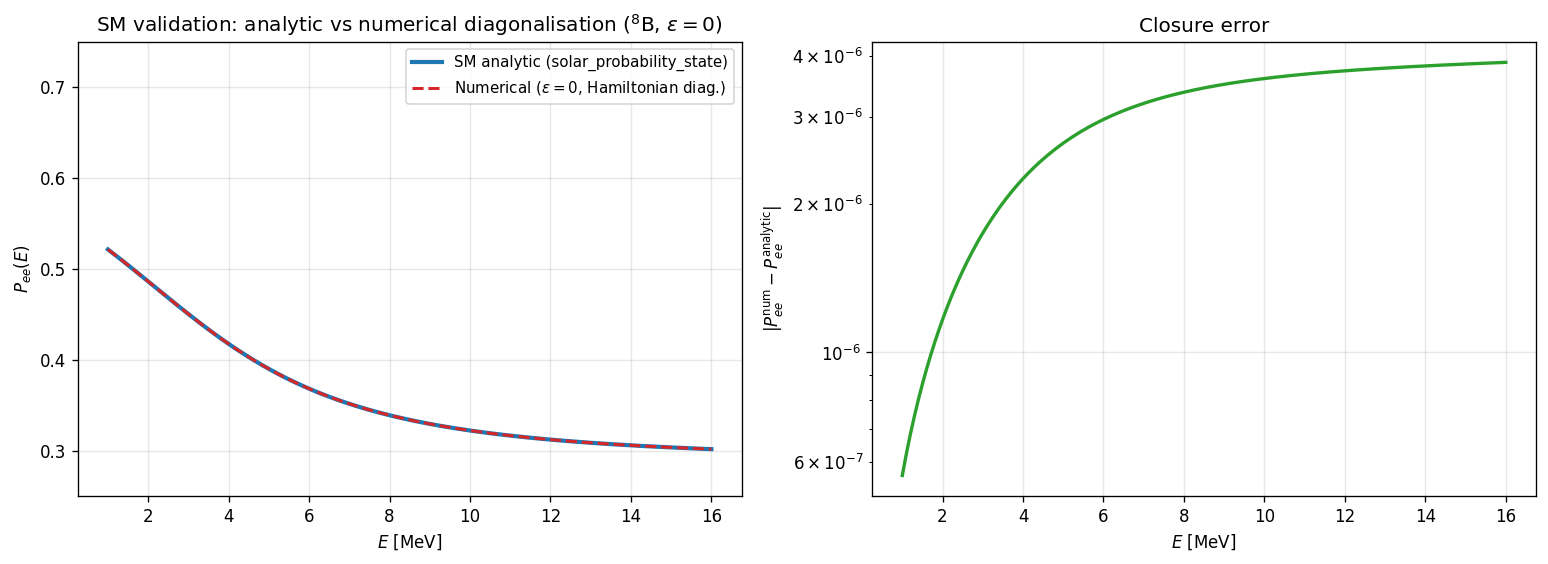

v:\output\analysis\solar\sn5_fig3_sm_validation.png
Max |closure error| = 3.879e-06


In [5]:
E_val = torch.linspace(1.0, 16.0, 150, dtype=ctx.dtype)
E_val_np = to_numpy(E_val)

eps_zero = torch.zeros(3, 3, dtype=torch.complex128, device=ctx.device)

# Analytic SM path
p_sm_analytic = solar_probability_state(oscillation, E_val, profile, NSI_SOURCE).detach()
pee_sm_analytic = to_numpy(p_sm_analytic[:, 0])

# Numerical diagonalisation with epsilon=0
p_sm_numerical = psolar_hamiltonian(E_val, NSI_SOURCE, epsilon=eps_zero).detach()
pee_sm_numerical = to_numpy(p_sm_numerical[:, 0])

diff_val = np.abs(pee_sm_numerical - pee_sm_analytic)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(E_val_np, pee_sm_analytic, '#1f77b4', lw=2.5, label='SM analytic (solar_probability_state)')
axes[0].plot(E_val_np, pee_sm_numerical, '#d62728', lw=1.8, ls='--',
             label=r'Numerical ($\varepsilon=0$, Hamiltonian diag.)')
axes[0].set_xlabel('$E$ [MeV]')
axes[0].set_ylabel(r'$P_{ee}(E)$')
axes[0].set_title(r'SM validation: analytic vs numerical diagonalisation ($^8$B, $\varepsilon=0$)')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0.25, 0.75)

axes[1].semilogy(E_val_np, np.maximum(diff_val, 1e-18), '#2ca02c', lw=2)
#axes[1].axhline(2.2e-16, color='gray', ls='--', lw=1, alpha=0.7,
#               label=r'float64 machine $\varepsilon \approx 2.2\times10^{-16}$')
axes[1].set_xlabel('$E$ [MeV]')
axes[1].set_ylabel(r'$|P_{ee}^{\rm num} - P_{ee}^{\rm analytic}|$')
axes[1].set_title('Closure error')
#axes[1].legend(fontsize=9)
fig.tight_layout()
save_and_show('sn5_fig3_sm_validation.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'Max |closure error| = {diff_val.max():.3e}')

## 4. SM vs NSI Presets

Five NSI benchmark scenarios (plus the SM baseline) are compared against the standard `solar_probability_state` result. The presets are loaded from `NSIConfig` and span diagonal, off-diagonal, and mixed NSI couplings from different experimental benchmarks.

### 4.1 Preset Catalogue

The table below summarises the $\boldsymbol{\varepsilon}$ entries and physical motivation for each preset.

| Preset | $\varepsilon_{ee}$ | $\varepsilon_{\tau\tau}$ | $\varepsilon_{e\tau}$ | $\varepsilon_{\mu\tau}$ | Reference |
|--------|-------------------:|-------------------------:|----------------------:|------------------------:|-----------|
| `sm_no_nsi` | 0 | 0 | 0 | 0 | SM baseline |
| `nsi_diagonal_biggio2009` | $+0.30$ | $+0.15$ | 0 | 0 | Biggio et al. (2009), arXiv:0907.0097 — 90% CL bounds |
| `nsi_offdiag_icecube2022` | 0 | $+0.015$ | 0 | $+0.005$ | IceCube (2022), arXiv:2112.09122 — $\mu\tau$ sector |
| `nsi_dune_etau` | 0 | 0 | $+0.15$ | 0 | DUNE sensitivity study, arXiv:2008.12769 |
| `nsi_hyperk_etau` | $+0.20$ | 0 | $+0.10$ | 0 | Hyper-K NSI benchmark, arXiv:1502.05199 |
| `nsi_globalfit_esteban2018` | $+0.25$ | $+0.08$ | $+0.12$ | $+0.01$ | Esteban et al. global fit (2018), arXiv:1805.04530 |

**Expected results:** 
- The code below prints each preset's label and description, confirming that `NSIConfig.from_preset` loads the correct parameters.

In [6]:
nsi_configs = {name: NSIConfig.from_preset(name) for name in NSI_PRESET_NAMES}

print(f'{"Preset":<35} {"is_SM":>6}  Description (truncated)')
print('-' * 90)
for name, cfg in nsi_configs.items():
    desc = (cfg.description or '')[:60].replace('\n', ' ')
    print(f'{name:<35} {str(cfg.is_sm_limit):>6}  {desc}...')

Preset                               is_SM  Description (truncated)
------------------------------------------------------------------------------------------
sm_no_nsi                             True  Standard Model: all NSI parameters set to zero. Passing this...
nsi_diagonal_biggio2009              False  Diagonal-only NSI at representative allowed values. Within t...
nsi_offdiag_icecube2022              False  Off-diagonal NSI in the mu-tau sector near the IceCube DeepC...
nsi_dune_etau                        False  Representative DUNE propagation NSI benchmark with eps_e_tau...
nsi_hyperk_etau                      False  Representative Hyper-K propagation NSI benchmark with eps_ee...
nsi_globalfit_esteban2018            False  Propagation NSI benchmark inspired by the global analysis of...


### 4.2 Survival Probability Comparison

The electron-neutrino survival probability for the $^8$B source is computed for all six scenarios. The left panel shows the absolute $P_{ee}(E)$; the right panel shows $\Delta P_{ee} = P_{ee}^{\rm NSI} - P_{ee}^{\rm SM}$ in percentage points, isolating the NSI deformation of the MSW transition relative to the SM baseline.

**Expected results:**
- **Diagonal Biggio09** ($\varepsilon_{ee}>0$): strengthened MSW potential → $P_{ee}$ shifted downward at low-to-mid energies.
- **IceCube off-diagonal** ($\varepsilon_{\mu\tau}$, $\varepsilon_{\tau\tau}$): primarily affects the $\nu_\mu/\nu_\tau$ sector; mild distortion of $P_{ee}$.
- **DUNE $e\tau$** ($\varepsilon_{e\tau}=0.15$): off-diagonal coupling between $\nu_e$ and $\nu_\tau$ creates a new MSW-like crossing → non-monotonic $\Delta P_{ee}$.
- **Hyper-K** (combined $\varepsilon_{ee}+\varepsilon_{e\tau}$): mixed effect with both a potential shift and a flavour-changing distortion.
- **Esteban2018 global fit**: most complex pattern, combining diagonal and off-diagonal entries across all three flavours.

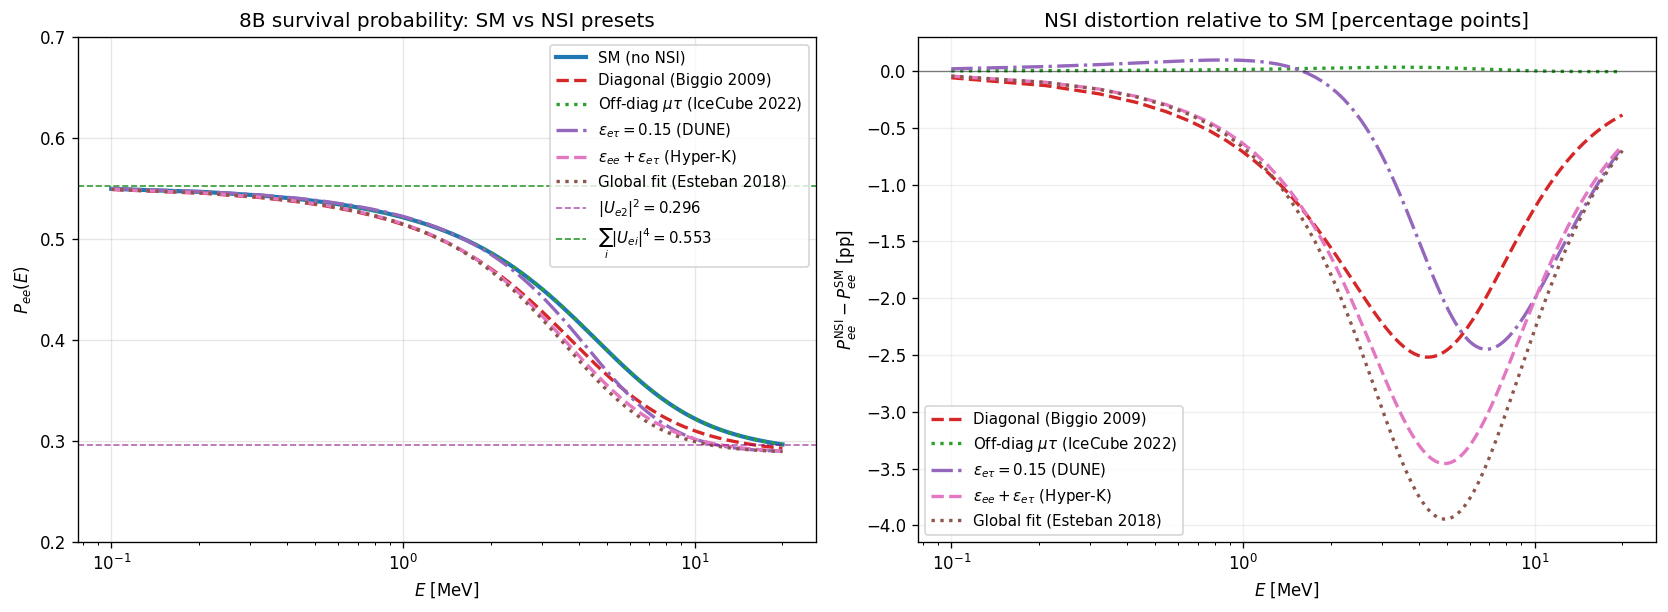

v:\output\analysis\solar\sn5_fig4_nsi_presets.png

Preset                               Pee(10MeV)  DeltaPee(10MeV)
-----------------------------------------------------------------
sm_no_nsi                                0.3222            (ref)
nsi_diagonal_biggio2009                  0.3102          -0.0121
nsi_offdiag_icecube2022                  0.3222          +0.0000
nsi_dune_etau                            0.3022          -0.0201
nsi_hyperk_etau                          0.3021          -0.0202
nsi_globalfit_esteban2018                0.2994          -0.0228


In [7]:
E_nsi    = torch.linspace(0.1, 20.0, 180, dtype=ctx.dtype)
E_nsi_np = to_numpy(E_nsi)

nsi_probs = {}
for name, cfg in nsi_configs.items():
    oscillation_nsi = dataclasses.replace(
        oscillation, nsi=None if cfg.is_sm_limit else cfg,
    )
    nsi_probs[name] = solar_probability_state(
        oscillation_nsi, E_nsi, profile, NSI_SOURCE,
    ).detach()

pee_sm_ref = to_numpy(nsi_probs['sm_no_nsi'][:, 0])

Ue2_sq      = float((torch.cos(pmns.params.theta13)**2) * (torch.sin(pmns.params.theta12)**2))
Uei_sq      = torch.stack([
    (torch.cos(pmns.params.theta13)**2) * (torch.cos(pmns.params.theta12)**2),
    (torch.cos(pmns.params.theta13)**2) * (torch.sin(pmns.params.theta12)**2),
    (torch.sin(pmns.params.theta13)**2),
])
Pee_vac_avg = float((Uei_sq**2).sum())

# Style: (linestyle, color, linewidth)
styles = {
    'sm_no_nsi':                   ('-',  '#1f77b4', 2.5),
    'nsi_diagonal_biggio2009':     ('--', '#d62728', 2.0),
    'nsi_offdiag_icecube2022':     (':',  '#2ca02c', 2.0),
    'nsi_dune_etau':               ('-.', '#9467bd', 2.0),
    'nsi_hyperk_etau':             ('--', '#e377c2', 2.0),
    'nsi_globalfit_esteban2018':   (':',  '#8c564b', 2.0),
}
labels = {
    'sm_no_nsi':                   'SM (no NSI)',
    'nsi_diagonal_biggio2009':     'Diagonal (Biggio 2009)',
    'nsi_offdiag_icecube2022':     'Off-diag $\\mu\\tau$ (IceCube 2022)',
    'nsi_dune_etau':               r'$\varepsilon_{e\tau}=0.15$ (DUNE)',
    'nsi_hyperk_etau':             r'$\varepsilon_{ee}+\varepsilon_{e\tau}$ (Hyper-K)',
    'nsi_globalfit_esteban2018':   'Global fit (Esteban 2018)',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

for name, probs in nsi_probs.items():
    ls, col, lw = styles[name]
    axes[0].plot(E_nsi_np, to_numpy(probs[:, 0]), ls=ls, color=col, lw=lw,
                label=labels[name])

axes[0].axhline(Ue2_sq,      color='purple', lw=1, ls='--', alpha=0.6,
               label=rf'$|U_{{e2}}|^2={Ue2_sq:.3f}$')
axes[0].axhline(Pee_vac_avg, color='g', lw=1, ls='--', alpha=0.8,
               label=rf'$\sum_i|U_{{ei}}|^4={Pee_vac_avg:.3f}$')
axes[0].set_xlabel('$E$ [MeV]')
axes[0].set_ylabel(r'$P_{ee}(E)$')
axes[0].set_title(rf'{NSI_SOURCE} survival probability: SM vs NSI presets')
axes[0].set_xscale('log')
axes[0].set_ylim(0.20, 0.70)
axes[0].legend(fontsize=9, loc='upper right')

for name, probs in nsi_probs.items():
    if name == 'sm_no_nsi':
        continue
    ls, col, lw = styles[name]
    axes[1].plot(E_nsi_np,
                to_numpy(probs[:, 0] - nsi_probs['sm_no_nsi'][:, 0]) * 100,
                ls=ls, color=col, lw=lw, label=labels[name])

axes[1].axhline(0, color='k', lw=0.8, alpha=0.5)
axes[1].set_xlabel('$E$ [MeV]')
axes[1].set_ylabel(r'$P_{ee}^{\rm NSI} - P_{ee}^{\rm SM}$ [pp]')
axes[1].set_title('NSI distortion relative to SM [percentage points]')
axes[1].set_xscale('log')
axes[1].legend(fontsize=9, loc="lower left")
axes[1].grid(True, alpha=0.2)
fig.tight_layout()
save_and_show('sn5_fig4_nsi_presets.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'\n{"Preset":<35}  {"Pee(10MeV)":>10}  {"DeltaPee(10MeV)":>15}')
print('-' * 65)
idx10 = int(np.argmin(np.abs(E_nsi_np - 10.0)))
for name, probs in nsi_probs.items():
    pee_val = float(probs[idx10, 0])
    delta   = pee_val - pee_sm_ref[idx10]
    tag     = f'{delta:+.4f}' if name != 'sm_no_nsi' else '  (ref)'
    print(f'{name:<35}  {pee_val:>10.4f}  {tag:>15}')

## 5. Diagonal NSI Scan — $\varepsilon_{ee}$

A continuous scan over $\varepsilon_{ee}\in[-0.6, 0.4]$ (other entries zero) shows how $P_{ee}$ shifts as the diagonal NSI coupling varies. Both a heatmap over the $(\varepsilon_{ee}, E)$ plane and a set of 1-D slices at fixed energies are shown.

**Expected results:**
- Negative $\varepsilon_{ee}$ pushes $P_{ee}$ upward (weakened MSW suppression);
- Positive $\varepsilon_{ee}$ pushes it downward.
- The effect is largest at low-to-mid energies.
- Near $\varepsilon_{ee}\approx -1$ the effective resonance disappears for high-energy neutrinos.

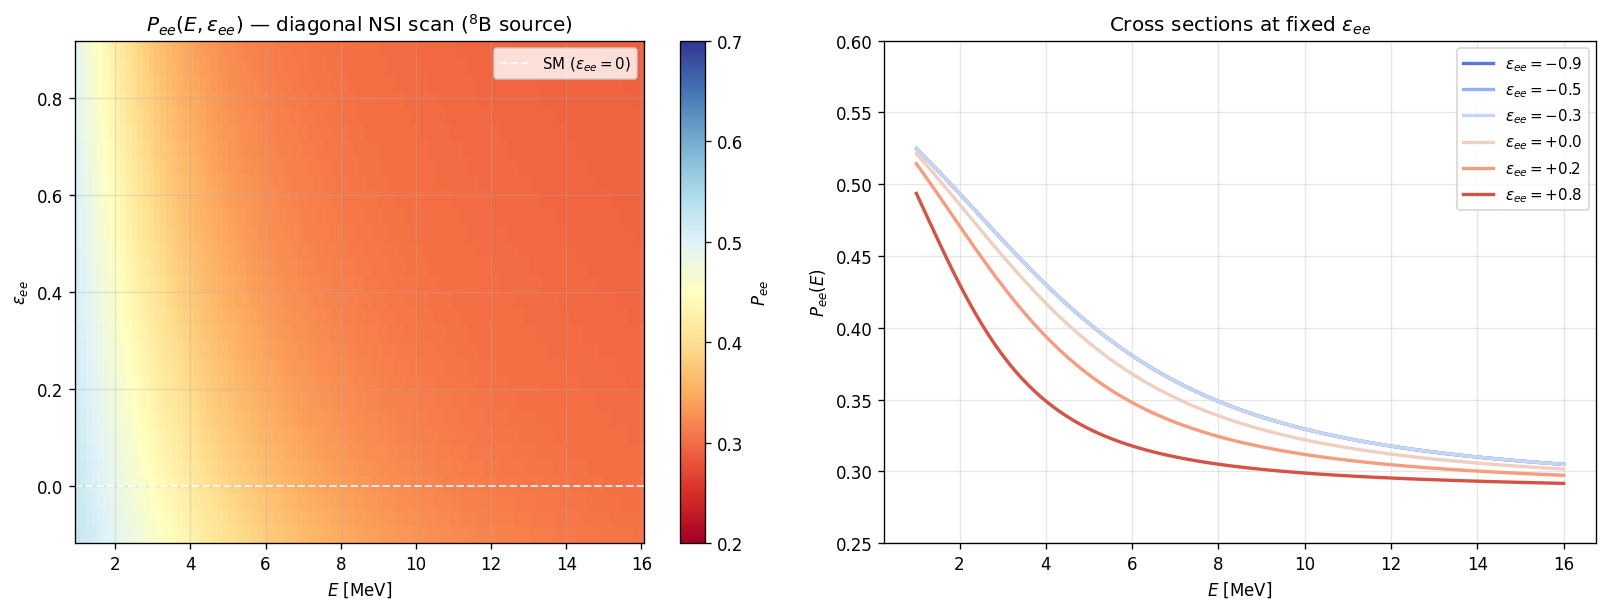

v:\output\analysis\solar\sn5_fig5_epsee_scan.png


In [8]:
eps_ee_vals = torch.linspace(-0.1, 0.9, 30, dtype=torch.float64)
E_scan      = torch.linspace(1.0, 16.0, 100, dtype=ctx.dtype)
E_scan_np   = to_numpy(E_scan)

pee_scan = np.zeros((len(eps_ee_vals), len(E_scan)))
for j, eps_val in enumerate(eps_ee_vals):
    eps_mat = torch.zeros(3, 3, dtype=torch.complex128, device=ctx.device)
    eps_mat[0, 0] = float(eps_val)
    p = solar_probability_state(oscillation_with_epsilon(eps_mat), E_scan, profile, NSI_SOURCE).detach()
    pee_scan[j] = to_numpy(p[:, 0])

eps_np = to_numpy(eps_ee_vals)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
mesh = axes[0].pcolormesh(E_scan_np, eps_np, pee_scan,
                           shading='auto', cmap='RdYlBu', vmin=0.2, vmax=0.7)
fig.colorbar(mesh, ax=axes[0], label=r'$P_{ee}$')
axes[0].set_xlabel('$E$ [MeV]')
axes[0].set_ylabel(r'$\varepsilon_{ee}$')
axes[0].set_title(r'$P_{ee}(E, \varepsilon_{ee})$ — diagonal NSI scan ($^8$B source)')
axes[0].axhline(0, color='white', lw=1.2, ls='--', alpha=0.8, label='SM ($\\varepsilon_{ee}=0$)')
axes[0].legend(fontsize=9)

probe_eps  = [-0.9, -0.5, -0.3, 0.0, 0.2, 0.8]
colors_eps = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(probe_eps)))
for eps_val, col in zip(probe_eps, colors_eps):
    j = int(np.argmin(np.abs(eps_np - eps_val)))
    axes[1].plot(E_scan_np, pee_scan[j], color=col, lw=2,
                label=rf'$\varepsilon_{{ee}}={eps_val:+.1f}$')
axes[1].set_xlabel('$E$ [MeV]')
axes[1].set_ylabel(r'$P_{ee}(E)$')
axes[1].set_title(r'Cross sections at fixed $\varepsilon_{ee}$')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0.25, 0.6)
fig.tight_layout()
save_and_show('sn5_fig5_epsee_scan.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 6. Off-Diagonal NSI — $\varepsilon_{e\mu}$ and $\varepsilon_{e\tau}$

Off-diagonal NSI entries introduce **flavour mixing in the matter sector** beyond the standard PMNS mixing. Unlike diagonal entries that merely shift potentials, off-diagonal $\varepsilon_{e\mu}$ and $\varepsilon_{e\tau}$ create new MSW-like level crossings between $\nu_e$ and $\nu_\mu/\nu_\tau$.

For real entries, the scan uses $\varepsilon_{e\mu}$ or $\varepsilon_{e\tau}$ at representative values with all other entries zero.

**Expected results:** 
- off-diagonal NSI produce asymmetric distortions (different for $\varepsilon_{e\mu}$ vs $\varepsilon_{e\tau}$)
- and non-monotonic features in $P_{ee}(E)$ due to additional level crossings.
- The magnitude of the effect depends on the NSI coupling strength.

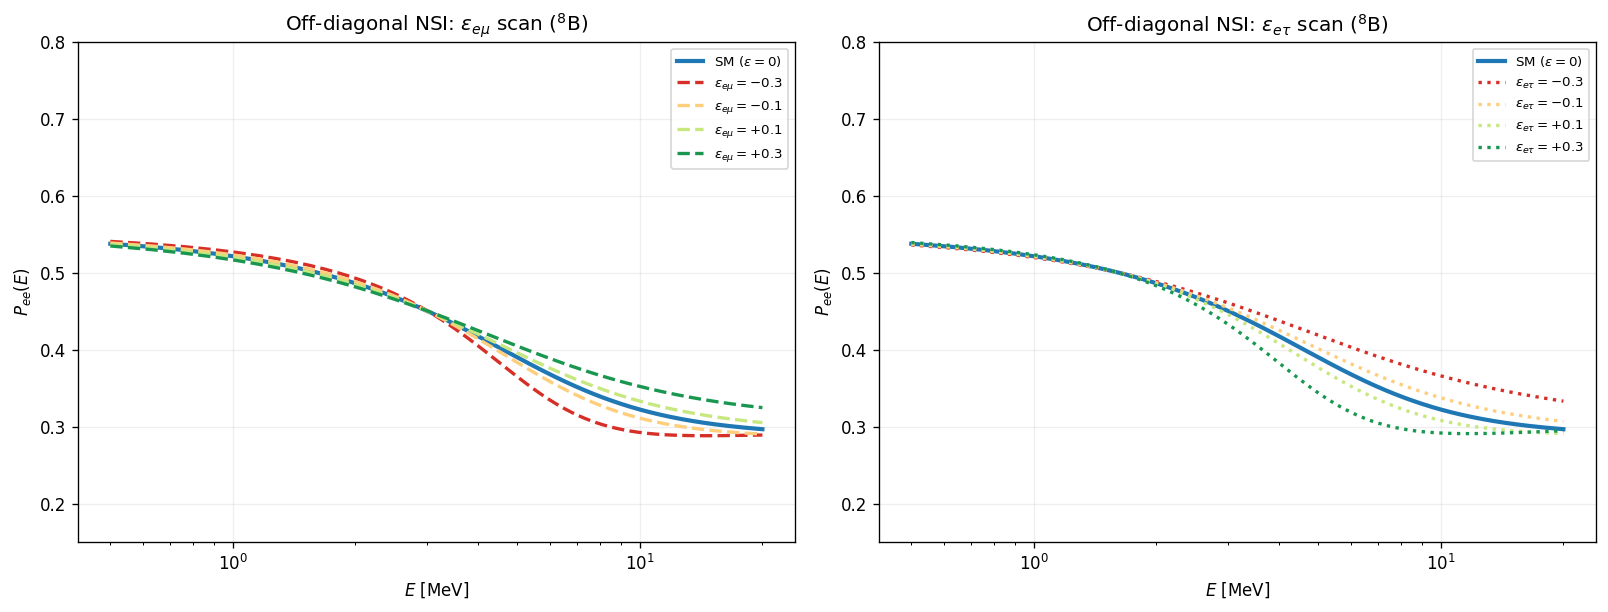

v:\output\analysis\solar\sn5_fig6_offdiag_nsi.png


In [9]:
E_od     = torch.linspace(0.5, 20.0, 150, dtype=ctx.dtype)
E_od_np  = to_numpy(E_od)

# Reference SM
p_sm_od = to_numpy(solar_probability_state(oscillation, E_od, profile, NSI_SOURCE).detach()[:, 0])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
for ax in axes:
    ax.plot(E_od_np, p_sm_od, '#1f77b4', lw=2.5, label='SM ($\\varepsilon=0$)')

eps_emue_vals = [-0.3, -0.1, 0.1, 0.3]
colors_od     = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(eps_emue_vals)))

for eps_val, col in zip(eps_emue_vals, colors_od):
    # epsilon_emu (real, symmetric)
    eps_emu = torch.zeros(3, 3, dtype=torch.complex128, device=ctx.device)
    eps_emu[0, 1] = eps_val;  eps_emu[1, 0] = eps_val
    p_emu = to_numpy(solar_probability_state(oscillation_with_epsilon(eps_emu), E_od,
                            profile, NSI_SOURCE).detach()[:, 0])
    axes[0].plot(E_od_np, p_emu, color=col, lw=2, ls='--',
                label=rf'$\varepsilon_{{e\mu}}={eps_val:+.1f}$')

    # epsilon_etau (real, symmetric)
    eps_etau = torch.zeros(3, 3, dtype=torch.complex128, device=ctx.device)
    eps_etau[0, 2] = eps_val;  eps_etau[2, 0] = eps_val
    p_etau = to_numpy(solar_probability_state(oscillation_with_epsilon(eps_etau), E_od,
                             profile, NSI_SOURCE).detach()[:, 0])
    axes[1].plot(E_od_np, p_etau, color=col, lw=2, ls=':',
                label=rf'$\varepsilon_{{e\tau}}={eps_val:+.1f}$')

for ax, title in zip(axes,
    [r'Off-diagonal NSI: $\varepsilon_{e\mu}$ scan ($^8$B)',
     r'Off-diagonal NSI: $\varepsilon_{e\tau}$ scan ($^8$B)']):
    ax.set_xlabel('$E$ [MeV]')
    ax.set_ylabel(r'$P_{ee}(E)$')
    ax.set_title(title)
    ax.set_xscale('log')
    ax.set_ylim(0.15, 0.80)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.tight_layout()
save_and_show('sn5_fig6_offdiag_nsi.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## ∑. Summary

| NSI type | Effect on $P_{ee}$ | Sensitivity |
|----------|--------------------|-------------|
| Diagonal $\varepsilon_{ee}<0$ | Shifts upward, weaker MSW suppression | Largest at $E\sim 3$–8 MeV |
| Diagonal $\varepsilon_{ee}>0$ | Shifts downward, stronger suppression | Same energy range |
| Off-diagonal $\varepsilon_{e\mu}$ | Non-monotonic distortion | Depends on sign |
| Off-diagonal $\varepsilon_{e\tau}$ | Different pattern from $\varepsilon_{e\mu}$ | Depends on sign |

**Physical interpretation:**

1. The numerical diagonalisation path in `tpeanuts` handles arbitrary Hermitian $\boldsymbol{\varepsilon}$ without any approximation. The closure test ($\varepsilon=0$ vs analytic) confirms agreement at $\lesssim 10^{-5}$ — the intrinsic accuracy of the analytic path's mixing-angle factorization (Section 3), well below any physical precision requirement, but *not* floating-point-level, since the analytic and numerical paths use genuinely different (both valid) computational strategies.
2. Diagonal $\varepsilon_{ee}$ simply rescales the effective matter potential $V_{\rm eff} = \sqrt{2}G_F n_e(1+\varepsilon_{ee})$, shifting the resonance energy without creating new crossings. The observable effect is a monotonic shift of the MSW transition region.
3. Off-diagonal entries introduce new level crossings between $\nu_e$ and $\nu_\mu/\nu_\tau$ that have no SM analogue. These create additional bumps or dips in $P_{ee}(E)$ that could, in principle, be distinguished from pure diagonal NSI with sufficient energy resolution.
4. Current constraints ($|\varepsilon_{e\alpha}|\lesssim 0.3$–$0.5$) allow $\mathcal{O}(5$–$15\%)$ shifts in $P_{ee}$ that are within the reach of next-generation solar-neutrino experiments.
5. The `epsilon` interface in `solar_probability_state` is fully compatible with the rest of the `tpeanuts` pipeline — the same NSI matrix can be passed through Earth propagation for joint solar+Earth analyses.

In [10]:
print('Summary — Solar Neutrino Analysis 5: NSI New Physics')
print('-'*65)
print(f'SM closure error (eps=0 vs analytic) : {diff_val.max():.3e}')
print()
print('DeltaPee at 10 MeV for NSI presets:')
for name, probs in nsi_probs.items():
    if name == 'sm_no_nsi': continue
    idx = int(np.argmin(np.abs(E_nsi_np - 10.0)))
    dP  = float(probs[idx, 0]) - pee_sm_ref[idx]
    print(f'  {name:40s}: {dP:+.4f}')
print()
print(f'Diagonal eps_ee scan: {len(eps_ee_vals)} points in [{float(eps_ee_vals[0]):.2f}, {float(eps_ee_vals[-1]):.2f}]')
print(f'max P_ee in scan : {pee_scan.max():.4f}')
print(f'min P_ee in scan : {pee_scan.min():.4f}')

Summary — Solar Neutrino Analysis 5: NSI New Physics
-----------------------------------------------------------------
SM closure error (eps=0 vs analytic) : 3.879e-06

DeltaPee at 10 MeV for NSI presets:
  nsi_diagonal_biggio2009                 : -0.0121
  nsi_offdiag_icecube2022                 : +0.0000
  nsi_dune_etau                           : -0.0201
  nsi_hyperk_etau                         : -0.0202
  nsi_globalfit_esteban2018               : -0.0228

Diagonal eps_ee scan: 30 points in [-0.10, 0.90]
max P_ee in scan : 0.5248
min P_ee in scan : 0.2910
